# 03 — Albert Street Duplicate Sensitivity Analysis

This notebook compares the Albert Street before-and-after results using:

1. the original raw records; and
2. the same records after removing exact duplicate rows.

The purpose is to determine whether duplicate records materially change the estimated before-and-after result.

## Analysis rules

- Counter: **9077 — Albert Street**
- Intervention date: **4 June 2020**
- Only observed days are analysed.
- Missing dates are not filled and are not treated as zero.
- The intervention date itself is excluded.
- Exact duplicates are removed only in the cleaned version.
- The original source file is never overwritten.


## 1. Import libraries and configure paths


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


from pathlib import Path
import os
import yaml

def find_project_root(start=None):
    """Find the repository root by looking for .git or config.yaml."""
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() or (candidate / "config.yaml").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()

config_path = PROJECT_ROOT / "config.yaml"
config = {}
if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f) or {}

paths_cfg = config.get("paths", {})

RAW_ROOT = PROJECT_ROOT / paths_cfg.get("raw_dir", "data/raw")
PROCESSED_ROOT = PROJECT_ROOT / paths_cfg.get("processed_dir", "data/processed")

# Optional override for local machines:
# Windows PowerShell example:
#   $env:CYCLING_DATA_DIR="D:\\path\\to\\CYCLING_DATA"
CYCLING_DATA_DIR = Path(
    os.environ.get(
        "CYCLING_DATA_DIR",
        RAW_ROOT / "cycling_data"
    )
).expanduser().resolve()

CYCLING_PROCESSED_DIR = PROCESSED_ROOT / "cycling_counters"
CYCLING_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cycling raw data:", CYCLING_DATA_DIR)
print("Cycling processed data:", CYCLING_PROCESSED_DIR)

EXTRACTION_DIR = CYCLING_PROCESSED_DIR / "extraction"
OUTPUT_DIR = CYCLING_PROCESSED_DIR / "duplicate_sensitivity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILE = EXTRACTION_DIR / "cycling_required_counters_raw.csv"
DUPLICATE_FILE = EXTRACTION_DIR / "duplicate_records.csv"
DAILY_FILE = EXTRACTION_DIR / "daily_bicycle_volume.csv"

print("Output folder:", OUTPUT_DIR)


Project root: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning
Cycling raw data: C:\Users\f_tir\OneDrive\Documents\UNI_2026\CAPSTONE PROJECT\A- TEAM A\CYCLING_DATA
Cycling processed data: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters
Output folder: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\duplicate_sensitivity


## 2. Load Albert Street raw records


In [2]:
SITE_ID = 9077
STREET_NAME = "Albert Street"
INTERVENTION_DATE = pd.Timestamp("2020-06-04")

raw = pd.read_csv(
    RAW_FILE,
    low_memory=False
)

raw["SITE_ID"] = pd.to_numeric(
    raw["SITE_ID"],
    errors="coerce"
)

raw["DATE_PARSED"] = pd.to_datetime(
    raw["DATE_PARSED"],
    errors="coerce"
)

albert_raw = (
    raw.loc[raw["SITE_ID"] == SITE_ID]
    .copy()
    .sort_values("DATE_PARSED")
)

if albert_raw.empty:
    raise ValueError(
        f"No records were found for Albert Street counter {SITE_ID}."
    )

print("Albert raw rows:", len(albert_raw))
print("First date:", albert_raw["DATE_PARSED"].min().date())
print("Last date:", albert_raw["DATE_PARSED"].max().date())

albert_raw.head()


Albert raw rows: 902230
First date: 2019-01-01
Last date: 2022-12-25


,DATA_TYPE,TIS_DATA_REQUEST,SITE_XN_ROUTE,LOC_LEG,DATE,TIME,CLASS,LANE,SPEED,WHEELBASE,...,AXLE,AXLE_GROUPING,RHO,VEHICLE,DIRECTION,SITE_ID,SOURCE_ZIP,SOURCE_CSV,DATE_PARSED,STREET
758944,IND,208,9077,40292,01/01/2019,00:03:55,15,2,23.1,1.1,...,2,1,1.0,CYCLE,W,9077,2019-01-06_IND.zip,IND_D208_X9077.csv,2019-01-01,Albert Street
760724,IND,208,9077,23042,01/01/2019,17:38:33,15,1,19.2,1.0,...,2,1,1.0,CYCLE,E,9077,2019-01-07_IND.zip,IND_D208_X9077.csv,2019-01-01,Albert Street
760723,IND,208,9077,23042,01/01/2019,17:27:12,15,1,25.0,1.0,...,2,1,1.0,CYCLE,E,9077,2019-01-07_IND.zip,IND_D208_X9077.csv,2019-01-01,Albert Street
760722,IND,208,9077,23042,01/01/2019,17:26:47,15,1,19.2,1.0,...,2,1,1.0,CYCLE,E,9077,2019-01-07_IND.zip,IND_D208_X9077.csv,2019-01-01,Albert Street
760721,IND,208,9077,23042,01/01/2019,17:26:32,15,1,22.3,1.0,...,2,1,1.0,CYCLE,E,9077,2019-01-07_IND.zip,IND_D208_X9077.csv,2019-01-01,Albert Street


## 3. Create a deduplicated copy


In [3]:
albert_clean = albert_raw.drop_duplicates().copy()

rows_removed = len(albert_raw) - len(albert_clean)
duplicate_percentage = (
    rows_removed / len(albert_raw) * 100
)

print("Original rows:", len(albert_raw))
print("Rows after exact deduplication:", len(albert_clean))
print("Exact duplicate rows removed:", rows_removed)
print(f"Rows removed as percentage of original: {duplicate_percentage:.4f}%")


Original rows: 902230
Rows after exact deduplication: 901867
Exact duplicate rows removed: 363
Rows removed as percentage of original: 0.0402%


## 4. Aggregate both datasets to daily bicycle counts

Each raw row represents one bicycle detection. Daily counts are therefore calculated by counting raw records for each date.


In [4]:
daily_original = (
    albert_raw
    .dropna(subset=["DATE_PARSED"])
    .groupby("DATE_PARSED")
    .size()
    .rename("BICYCLE_DETECTIONS")
    .reset_index()
    .sort_values("DATE_PARSED")
)

daily_clean = (
    albert_clean
    .dropna(subset=["DATE_PARSED"])
    .groupby("DATE_PARSED")
    .size()
    .rename("BICYCLE_DETECTIONS")
    .reset_index()
    .sort_values("DATE_PARSED")
)

print("Observed days in original:", len(daily_original))
print("Observed days after deduplication:", len(daily_clean))


Observed days in original: 1287
Observed days after deduplication: 1287


## 5. Compare daily counts before and after deduplication


In [5]:
daily_impact = daily_original.merge(
    daily_clean,
    on="DATE_PARSED",
    how="outer",
    suffixes=("_ORIGINAL", "_DEDUPLICATED")
).fillna(0)

daily_impact["COUNT_DIFFERENCE"] = (
    daily_impact["BICYCLE_DETECTIONS_ORIGINAL"]
    - daily_impact["BICYCLE_DETECTIONS_DEDUPLICATED"]
)

days_affected = int(
    (daily_impact["COUNT_DIFFERENCE"] > 0).sum()
)

maximum_daily_reduction = int(
    daily_impact["COUNT_DIFFERENCE"].max()
)

total_reduction = int(
    daily_impact["COUNT_DIFFERENCE"].sum()
)

print("Days affected by duplicate removal:", days_affected)
print("Maximum reduction on one day:", maximum_daily_reduction)
print("Total detections removed:", total_reduction)

daily_impact.sort_values(
    "COUNT_DIFFERENCE",
    ascending=False
).head(20)


Days affected by duplicate removal: 202
Maximum reduction on one day: 13
Total detections removed: 363


,DATE_PARSED,BICYCLE_DETECTIONS_ORIGINAL,BICYCLE_DETECTIONS_DEDUPLICATED,COUNT_DIFFERENCE
46,2019-02-16,535,522,13
56,2019-02-26,1971,1961,10
584,2021-01-22,652,642,10
583,2021-01-21,495,486,9
590,2021-01-28,710,701,9
183,2019-07-03,1298,1292,6
9,2019-01-10,1574,1569,5
105,2019-04-16,1788,1783,5
161,2019-06-11,1538,1533,5
49,2019-02-19,1833,1829,4


## 6. Define a reusable before-and-after function


In [6]:
def calculate_before_after(
    daily_data: pd.DataFrame,
    count_column: str,
    method_name: str
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Calculate observed-day before-and-after statistics.
    """

    data = daily_data.copy()

    data = data.loc[
        data["DATE_PARSED"] != INTERVENTION_DATE
    ].copy()

    data["PERIOD"] = "Before"

    data.loc[
        data["DATE_PARSED"] > INTERVENTION_DATE,
        "PERIOD"
    ] = "After"

    result = (
        data
        .groupby("PERIOD", as_index=False)
        .agg(
            FIRST_OBSERVED_DATE=("DATE_PARSED", "min"),
            LAST_OBSERVED_DATE=("DATE_PARSED", "max"),
            OBSERVED_DAYS=("DATE_PARSED", "count"),
            TOTAL_BICYCLE_DETECTIONS=(count_column, "sum"),
            AVERAGE_DAILY_COUNT=(count_column, "mean"),
            MEDIAN_DAILY_COUNT=(count_column, "median"),
            STANDARD_DEVIATION=(count_column, "std")
        )
    )

    period_order = pd.CategoricalDtype(
        categories=["Before", "After"],
        ordered=True
    )

    result["PERIOD"] = result["PERIOD"].astype(period_order)
    result = result.sort_values("PERIOD").reset_index(drop=True)

    before_avg = result.loc[
        result["PERIOD"] == "Before",
        "AVERAGE_DAILY_COUNT"
    ].iloc[0]

    after_avg = result.loc[
        result["PERIOD"] == "After",
        "AVERAGE_DAILY_COUNT"
    ].iloc[0]

    absolute_change = after_avg - before_avg
    percentage_change = (
        absolute_change / before_avg
    ) * 100

    summary = pd.DataFrame([{
        "METHOD": method_name,
        "BEFORE_AVERAGE_DAILY_COUNT": before_avg,
        "AFTER_AVERAGE_DAILY_COUNT": after_avg,
        "ABSOLUTE_CHANGE": absolute_change,
        "PERCENTAGE_CHANGE": percentage_change
    }])

    result["METHOD"] = method_name

    return result, summary


## 7. Run the analysis on the original and deduplicated datasets


In [7]:
original_result, original_summary = calculate_before_after(
    daily_original,
    "BICYCLE_DETECTIONS",
    "Original raw data"
)

clean_result, clean_summary = calculate_before_after(
    daily_clean,
    "BICYCLE_DETECTIONS",
    "Exact duplicates removed"
)

period_comparison = pd.concat(
    [original_result, clean_result],
    ignore_index=True
)

summary_comparison = pd.concat(
    [original_summary, clean_summary],
    ignore_index=True
)

display(period_comparison)
display(summary_comparison)


,PERIOD,FIRST_OBSERVED_DATE,LAST_OBSERVED_DATE,OBSERVED_DAYS,TOTAL_BICYCLE_DETECTIONS,AVERAGE_DAILY_COUNT,MEDIAN_DAILY_COUNT,STANDARD_DEVIATION,METHOD
0,Before,2019-01-01,2020-06-03,352,330839,939.883523,933.0,551.735832,Original raw data
1,After,2020-06-05,2022-12-25,934,570803,611.138116,544.0,277.115299,Original raw data
2,Before,2019-01-01,2020-06-03,352,330643,939.326705,932.5,551.259416,Exact duplicates removed
3,After,2020-06-05,2022-12-25,934,570636,610.959315,544.0,277.019179,Exact duplicates removed


,METHOD,BEFORE_AVERAGE_DAILY_COUNT,AFTER_AVERAGE_DAILY_COUNT,ABSOLUTE_CHANGE,PERCENTAGE_CHANGE
0,Original raw data,939.883523,611.138116,-328.745407,-34.97725
1,Exact duplicates removed,939.326705,610.959315,-328.367390,-34.95774


## 8. Measure the effect of deduplication on the final result


In [8]:
original_pct = summary_comparison.loc[
    summary_comparison["METHOD"] == "Original raw data",
    "PERCENTAGE_CHANGE"
].iloc[0]

clean_pct = summary_comparison.loc[
    summary_comparison["METHOD"] == "Exact duplicates removed",
    "PERCENTAGE_CHANGE"
].iloc[0]

percentage_point_difference = clean_pct - original_pct

original_before = summary_comparison.loc[
    summary_comparison["METHOD"] == "Original raw data",
    "BEFORE_AVERAGE_DAILY_COUNT"
].iloc[0]

clean_before = summary_comparison.loc[
    summary_comparison["METHOD"] == "Exact duplicates removed",
    "BEFORE_AVERAGE_DAILY_COUNT"
].iloc[0]

original_after = summary_comparison.loc[
    summary_comparison["METHOD"] == "Original raw data",
    "AFTER_AVERAGE_DAILY_COUNT"
].iloc[0]

clean_after = summary_comparison.loc[
    summary_comparison["METHOD"] == "Exact duplicates removed",
    "AFTER_AVERAGE_DAILY_COUNT"
].iloc[0]

impact_summary = pd.DataFrame([{
    "ORIGINAL_BEFORE_AVERAGE": original_before,
    "DEDUPLICATED_BEFORE_AVERAGE": clean_before,
    "BEFORE_AVERAGE_DIFFERENCE": clean_before - original_before,
    "ORIGINAL_AFTER_AVERAGE": original_after,
    "DEDUPLICATED_AFTER_AVERAGE": clean_after,
    "AFTER_AVERAGE_DIFFERENCE": clean_after - original_after,
    "ORIGINAL_PERCENTAGE_CHANGE": original_pct,
    "DEDUPLICATED_PERCENTAGE_CHANGE": clean_pct,
    "PERCENTAGE_POINT_DIFFERENCE": percentage_point_difference
}])

impact_summary


,ORIGINAL_BEFORE_AVERAGE,DEDUPLICATED_BEFORE_AVERAGE,BEFORE_AVERAGE_DIFFERENCE,ORIGINAL_AFTER_AVERAGE,DEDUPLICATED_AFTER_AVERAGE,AFTER_AVERAGE_DIFFERENCE,ORIGINAL_PERCENTAGE_CHANGE,DEDUPLICATED_PERCENTAGE_CHANGE,PERCENTAGE_POINT_DIFFERENCE
0,939.883523,939.326705,-0.556818,611.138116,610.959315,-0.178801,-34.97725,-34.95774,0.019509


## 9. Visual comparison


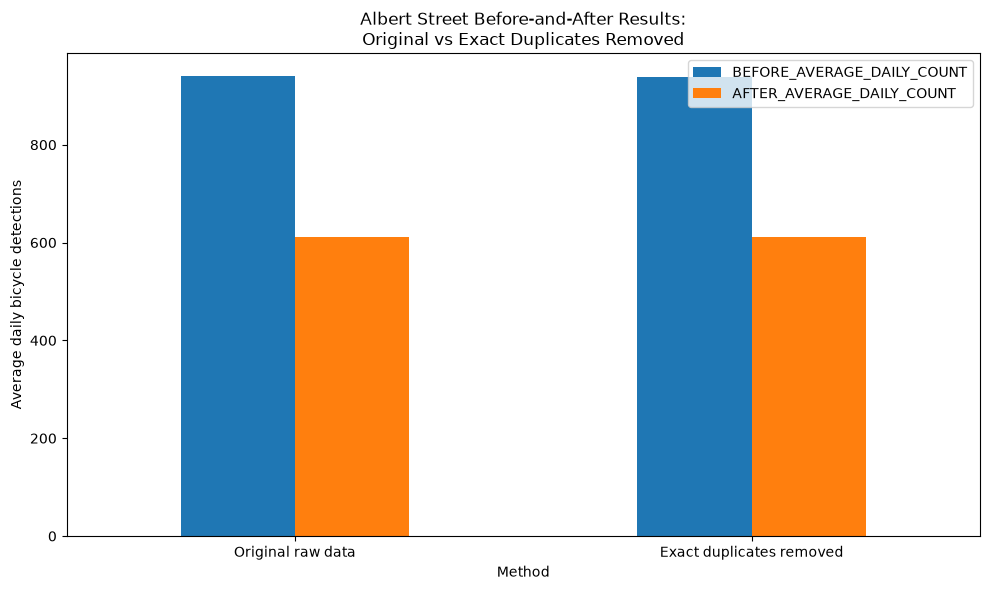

Saved: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\duplicate_sensitivity\albert_original_vs_deduplicated_before_after.png


In [9]:
plot_data = summary_comparison.set_index("METHOD")[
    [
        "BEFORE_AVERAGE_DAILY_COUNT",
        "AFTER_AVERAGE_DAILY_COUNT"
    ]
]

plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Albert Street Before-and-After Results:\n"
    "Original vs Exact Duplicates Removed"
)
plt.xlabel("Method")
plt.ylabel("Average daily bicycle detections")
plt.xticks(rotation=0)
plt.tight_layout()

chart_path = (
    OUTPUT_DIR
    / "albert_original_vs_deduplicated_before_after.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", chart_path)


## 10. Daily impact plot


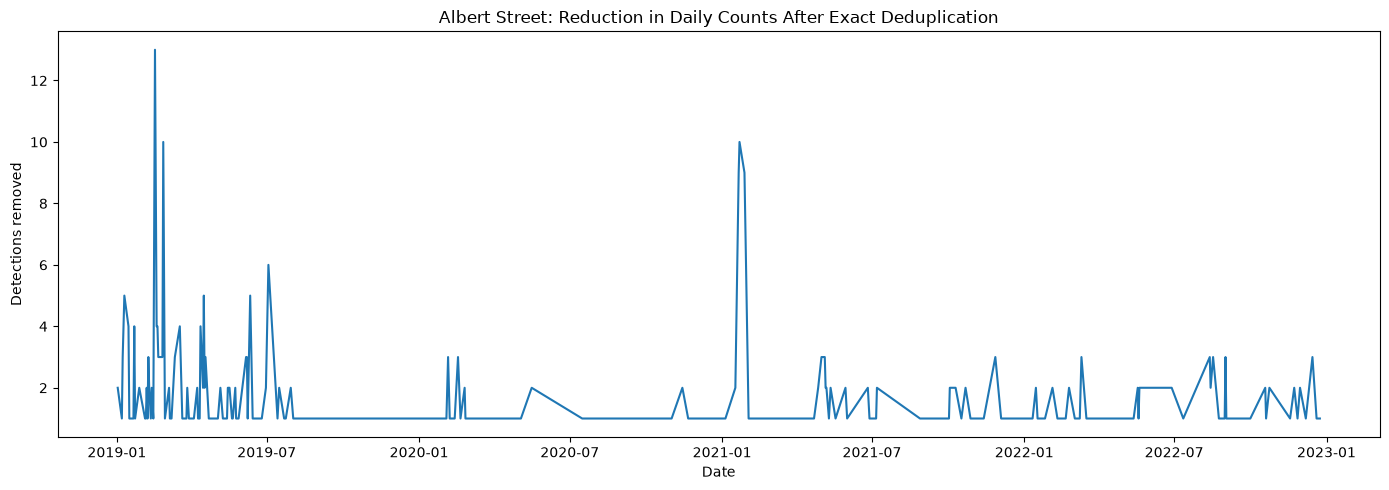

Saved: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\duplicate_sensitivity\albert_daily_duplicate_removal_impact.png


In [10]:
affected_days = daily_impact.loc[
    daily_impact["COUNT_DIFFERENCE"] > 0
].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    affected_days["DATE_PARSED"],
    affected_days["COUNT_DIFFERENCE"]
)

plt.title(
    "Albert Street: Reduction in Daily Counts After Exact Deduplication"
)
plt.xlabel("Date")
plt.ylabel("Detections removed")
plt.tight_layout()

impact_chart_path = (
    OUTPUT_DIR
    / "albert_daily_duplicate_removal_impact.png"
)

plt.savefig(
    impact_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", impact_chart_path)


## 11. Export results


In [11]:
period_comparison.to_csv(
    OUTPUT_DIR / "albert_period_results_original_vs_deduplicated.csv",
    index=False
)

summary_comparison.to_csv(
    OUTPUT_DIR / "albert_summary_original_vs_deduplicated.csv",
    index=False
)

impact_summary.to_csv(
    OUTPUT_DIR / "albert_duplicate_impact_summary.csv",
    index=False
)

daily_impact.to_csv(
    OUTPUT_DIR / "albert_daily_count_impact.csv",
    index=False
)

daily_clean.to_csv(
    OUTPUT_DIR / "albert_daily_counts_deduplicated.csv",
    index=False
)

albert_clean.to_csv(
    OUTPUT_DIR / "albert_raw_exact_duplicates_removed.csv",
    index=False
)

print("All outputs saved to:", OUTPUT_DIR)


All outputs saved to: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\duplicate_sensitivity


## 12. Interpretation guide

How we can use the results to decide whether duplicate removal materially changes the analysis:

### If the results are very similar

> Removing exact duplicate rows had only a small effect on the before and after averages and produced a minimal change in the estimated percentage difference. The duplicate issue was therefore documented, but it did not materially alter the overall before-and-after conclusion.

### If the results differ noticeably

> Removing exact duplicate rows changed the before and/or after averages and produced a meaningful change in the estimated percentage difference. Exact duplicates should therefore be removed before the final analysis, and the cleaning step should be documented.

### Important caution

Even after exact duplicate removal, the analysis still has other limitations, including the 168-day collection gap, the additional 6-day end gap, seasonal variation, COVID-19 disruptions and possible external influences.


## 12. Conclusion

The sensitivity analysis shows that removing exact duplicate records has a **negligible effect on the Albert Street before-and-after results**.

Exact duplicate removal:

- affected **202 observed days**;
- removed **363 bicycle detections**;
- produced a maximum reduction of **13 detections on a single day**.

The before-and-after results were:

| Dataset | Before average daily count | After average daily count | Percentage change |
|---|---:|---:|---:|
| Original raw data | 939.88 | 611.14 | -34.98% |
| Exact duplicates removed | 939.33 | 610.96 | -34.96% |

The estimated percentage change differed by only **0.02 percentage points** after exact duplicates were removed. Therefore, although duplicate records are a documented data-quality issue, their removal does **not materially change the overall Albert Street before-and-after result**.

For the cleaned analytical dataset, exact duplicate records can be removed while retaining the original raw data unchanged. The duplicate investigation and sensitivity analysis provide evidence for this cleaning decision.

### Important limitation

This sensitivity analysis only assesses the effect of **exact duplicate removal**. Other limitations remain, particularly the **168-day collection gap** in the before period and the additional **6-day end gap**. Seasonal variation, COVID-19 disruptions, and other external influences should also be considered when interpreting the before-and-after results.